In [ ]:
# ============================================================
# 셀 1: 최초 1회만 실행 (Drive에 모델 저장)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# ── 필수 패키지 설치 ──────────────────────────────────────
!pip install -q iopath hydra-core==1.3.2 omegaconf==2.3.0 kornia easydict tabulate webdataset albumentations==1.3.1 pytorch-lightning==1.9.5

DRIVE_DIR = '/content/drive/MyDrive/furniture_remover'
SAM2_DIR  = f'{DRIVE_DIR}/sam2'
LAMA_DIR  = f'{DRIVE_DIR}/lama_local'
MODEL_DIR = f'{DRIVE_DIR}/lama_model'

os.makedirs(DRIVE_DIR, exist_ok=True)

# ── SAM2 클론 ─────────────────────────────────────────────
if not os.path.exists(SAM2_DIR):
    print('📦 SAM2 클론 중...')
    !git clone https://github.com/facebookresearch/sam2.git {SAM2_DIR}
    !cd {SAM2_DIR} && pip install -q -e .
    print('✅ SAM2 클론 + 설치 완료!')
else:
    print('✅ SAM2 이미 존재!')

# ── SAM2 체크포인트 ───────────────────────────────────────
ckpt_path = f'{SAM2_DIR}/checkpoints/sam2.1_hiera_large.pt'
if not os.path.exists(ckpt_path):
    print('⬇️ SAM2 체크포인트 다운로드 중...')
    os.makedirs(f'{SAM2_DIR}/checkpoints', exist_ok=True)
    !wget -q --show-progress \
        https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt \
        -O {ckpt_path}
    print('✅ SAM2 체크포인트 완료!')
else:
    print('✅ SAM2 체크포인트 이미 존재!')

# ── LaMa 클론 + 패치 ──────────────────────────────────────
if not os.path.exists(LAMA_DIR):
    print('📦 LaMa 클론 중...')
    !git clone https://github.com/advimman/lama.git {LAMA_DIR}

    # ADE20K 파일 다운로드
    ade_dir = f'{LAMA_DIR}/models/ade20k'
    os.makedirs(ade_dir, exist_ok=True)
    !wget -q \
        'https://raw.githubusercontent.com/CSAILVision/semantic-segmentation-pytorch/master/data/object150_info.csv' \
        -O {ade_dir}/object150_info.csv
    print('✅ ADE20K 파일 다운로드 완료!')

    # aug.py 패치 (최신 albumentations 호환)
    aug_patch = '''import albumentations as A
from albumentations import DualTransform
import numpy as np

def to_tuple(param, low=None):
    if isinstance(param, tuple):
        return param
    if low is None:
        return (-param, param)
    return (low, param)

class IAAAffine2(DualTransform):
    def __init__(self, scale=1.0, always_apply=False, p=0.5):
        super().__init__(always_apply, p)
        self.scale = to_tuple(scale, 1.0) if not isinstance(scale, tuple) else scale
    def apply(self, img, **params):
        return img
    def apply_to_mask(self, img, **params):
        return img
    def get_transform_init_args_names(self):
        return ("scale",)

class IAAPerspective2(DualTransform):
    def __init__(self, scale=(0.05, 0.1), always_apply=False, p=0.5):
        super().__init__(always_apply, p)
        self.scale = scale
    def apply(self, img, **params):
        return img
    def apply_to_mask(self, img, **params):
        return img
    def get_transform_init_args_names(self):
        return ("scale",)
'''
    with open(f'{LAMA_DIR}/saicinpainting/training/data/aug.py', 'w') as f:
        f.write(aug_patch)

    # torch.load 패치 (weights_only 경고 해결)
    init_path = f'{LAMA_DIR}/saicinpainting/training/trainers/__init__.py'
    with open(init_path) as f:
        content = f.read()
    content = content.replace(
        'torch.load(path, map_location=map_location)',
        'torch.load(path, map_location=map_location, weights_only=False)'
    )
    with open(init_path, 'w') as f:
        f.write(content)
    print('✅ LaMa 클론 + 패치 완료!')
else:
    print('✅ LaMa 이미 존재!')

# ── LaMa 모델 다운로드 ────────────────────────────────────
ckpt_path = f'{MODEL_DIR}/big-lama/models/best.ckpt'
if not os.path.exists(ckpt_path):
    print('⬇️ big-lama 모델 다운로드 중...')
    os.makedirs(MODEL_DIR, exist_ok=True)

    # 불완전한 이전 다운로드 정리
    !rm -rf {MODEL_DIR}/big-lama.zip {MODEL_DIR}/big-lama

    !wget -q --show-progress \
        'https://huggingface.co/smartywu/big-lama/resolve/main/big-lama.zip' \
        -O {MODEL_DIR}/big-lama.zip
    !unzip -q {MODEL_DIR}/big-lama.zip -d {MODEL_DIR}/
    !rm {MODEL_DIR}/big-lama.zip

    # 다운로드 검증
    if os.path.exists(ckpt_path):
        print('✅ big-lama 모델 완료!')
    else:
        print('❌ 다운로드 실패 — 파일 구조 확인:')
        !ls -la {MODEL_DIR}/
else:
    print('✅ big-lama 모델 이미 존재!')

print('\n🎉 모든 파일 Drive 저장 완료!')
print('다음부터는 셀 2만 실행하면 됩니다!')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ============================================================
# 셀 2: 런타임 시작할 때마다 실행 (스마트 설치 + 모델 로드)
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, sys
DRIVE_DIR = '/content/drive/MyDrive/furniture_remover'
SAM2_DIR  = f'{DRIVE_DIR}/sam2'
LAMA_DIR  = f'{DRIVE_DIR}/lama_local'
MODEL_DIR = f'{DRIVE_DIR}/lama_model'

# ── 패키지 설치 여부 확인 함수 ────────────────────────────
def is_package_installed(package_name):
    import importlib
    try:
        importlib.import_module(package_name)
        return True
    except ImportError:
        return False

# ── 필요 패키지 목록 확인 ─────────────────────────────────
packages_to_check = {
    'hydra':             'hydra-core==1.3.2',
    'omegaconf':         'omegaconf==2.3.0',
    'kornia':            'kornia',
    'easydict':          'easydict',
    'tabulate':          'tabulate',
    'webdataset':        'webdataset',
    'albumentations':    'albumentations==1.3.1',
    'pytorch_lightning': 'pytorch-lightning==1.9.5',
    'iopath':            'iopath',
}

missing = []
for import_name, pip_name in packages_to_check.items():
    if not is_package_installed(import_name):
        missing.append(pip_name)
        print(f'  ❌ {import_name} → 설치 필요')
    else:
        print(f'  ✅ {import_name} → 이미 설치됨')

if missing:
    print(f'\n📦 {len(missing)}개 패키지 설치 중...')
    os.system(f'pip install -q {" ".join(missing)}')
    print('✅ 패키지 설치 완료!')
else:
    print('\n✅ 모든 패키지 이미 설치됨 — 스킵!')

# ── SAM2 설치 확인 (의존성까지 검증) ─────────────────────
def is_sam2_properly_installed():
    try:
        import sam2
        import iopath
        from sam2.build_sam import build_sam2
        return True
    except ImportError:
        return False

if not is_sam2_properly_installed():
    print('📦 SAM2 및 의존성 설치 중...')
    os.system('pip install -q iopath')
    os.system(f'cd {SAM2_DIR} && pip install -q -e .')
    print('✅ SAM2 설치 완료!')
else:
    print('✅ SAM2 이미 설치됨 — 스킵!')

# ── ADE20K 파일 확인 ──────────────────────────────────────
ade_csv = f'{LAMA_DIR}/models/ade20k/object150_info.csv'
if not os.path.exists(ade_csv):
    print('⬇️ ADE20K 파일 없음 → 다운로드 중...')
    os.makedirs(os.path.dirname(ade_csv), exist_ok=True)
    os.system(
        'wget -q '
        'https://raw.githubusercontent.com/CSAILVision/semantic-segmentation-pytorch/master/data/object150_info.csv '
        f'-O {ade_csv}'
    )
    print('✅ ADE20K 파일 다운로드 완료!')
else:
    print('✅ ADE20K 파일 이미 존재!')

# ── numpy 버전 확인 & 고정 ────────────────────────────────
import numpy as np
if not np.__version__.startswith('1.26'):
    print(f'⚠ numpy {np.__version__} 감지 → 1.26.4로 재설치 중...')
    os.system('pip install -q numpy==1.26.4')
    os.kill(os.getpid(), 9)
else:
    print(f'✅ numpy {np.__version__} — OK')

# ── 경로 설정 ─────────────────────────────────────────────
sys.path.insert(0, SAM2_DIR)
sys.path.insert(0, LAMA_DIR)

import torch, cv2, matplotlib.pyplot as plt
from PIL import Image
import io

print(f'numpy: {np.__version__}, Pillow: {Image.__version__}')

# ── SAM2 모델 로드 ────────────────────────────────────────
print('\n🔄 SAM2 로드 중...')
os.chdir(SAM2_DIR)
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
sam2_model = build_sam2(
    'configs/sam2.1/sam2.1_hiera_l.yaml',
    f'{SAM2_DIR}/checkpoints/sam2.1_hiera_large.pt',
    device='cuda'
)
predictor = SAM2ImagePredictor(sam2_model)
os.chdir('/content')
print('✅ SAM2 로드 완료!')

# ── LaMa 모델 로드 ───────────────────────────────────────
print('🔄 LaMa 로드 중...')
from omegaconf import OmegaConf
from saicinpainting.training.trainers import load_checkpoint
train_config = OmegaConf.load(f'{MODEL_DIR}/big-lama/config.yaml')
train_config.training_model.predict_only = True
train_config.visualizer.kind = 'noop'
lama_model = load_checkpoint(
    train_config,
    f'{MODEL_DIR}/big-lama/models/best.ckpt',
    strict=False,
    map_location='cpu'
)
lama_model.freeze()
lama_model.to('cuda')
print('✅ LaMa 로드 완료!')

print('\n🎉 모든 준비 완료!')

Mounted at /content/drive
  ✅ hydra → 이미 설치됨
  ✅ omegaconf → 이미 설치됨
  ✅ kornia → 이미 설치됨
  ✅ easydict → 이미 설치됨
  ✅ tabulate → 이미 설치됨
  ✅ webdataset → 이미 설치됨
  ✅ albumentations → 이미 설치됨
  ✅ pytorch_lightning → 이미 설치됨
  ✅ iopath → 이미 설치됨

✅ 모든 패키지 이미 설치됨 — 스킵!
✅ SAM2 이미 설치됨 — 스킵!
✅ ADE20K 파일 이미 존재!
✅ numpy 1.26.4 — OK
numpy: 1.26.4, Pillow: 11.3.0

🔄 SAM2 로드 중...
✅ SAM2 로드 완료!
🔄 LaMa 로드 중...
✅ LaMa 로드 완료!

🎉 모든 준비 완료!


📁 방 사진을 업로드하세요!


Saving Gemini_Generated_Image_dh4b81dh4b81dh4b.png to Gemini_Generated_Image_dh4b81dh4b81dh4b.png
이미지 크기: W=1024, H=558


/tmp/ipykernel_2998/2033272190.py:41: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/2033272190.py:41: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/2033272190.py:41: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/2033272190.py:41: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/2033272190.py:41: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/2033272190.py:41: UserWarning: Glyph 52285 (\N{HANGUL SYLLABLE CANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/2033272190.py:41: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layou

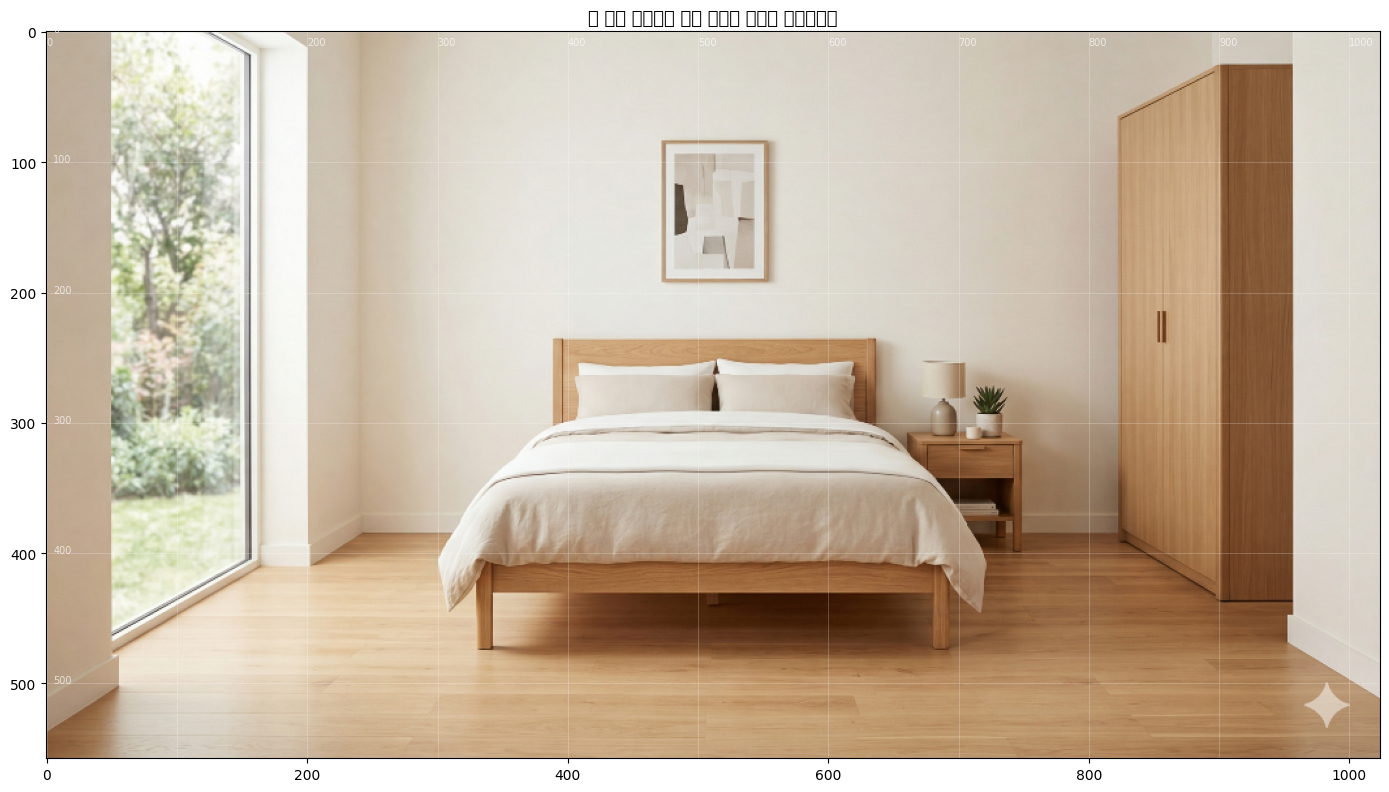

In [ ]:
# ============================================================
# 셀 3: 이미지 업로드 & 텍스트로 가구 선택
# ============================================================
%matplotlib inline
from google.colab import files
from IPython.display import display, clear_output
import ipywidgets as widgets
import io

print('📁 방 사진을 업로드하세요!')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
image_np = np.array(image)

# 리사이즈
MAX_SIZE = 1024
h, w = image_np.shape[:2]
if max(h, w) > MAX_SIZE:
    scale = MAX_SIZE / max(h, w)
    image_np = cv2.resize(image_np, (int(w*scale), int(h*scale)))

h, w = image_np.shape[:2]
print(f'이미지 크기: W={w}, H={h}')

# 이미지 미리보기 (격자 포함)
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(image_np)

# 격자 표시 (좌표 참고용)
grid_step = 100
for x in range(0, w, grid_step):
    ax.axvline(x, color='white', alpha=0.3, linewidth=0.5)
    ax.text(x, 10, str(x), color='white', fontsize=7, alpha=0.7)
for y in range(0, h, grid_step):
    ax.axhline(y, color='white', alpha=0.3, linewidth=0.5)
    ax.text(5, y, str(y), color='white', fontsize=7, alpha=0.7)

ax.set_title('📐 아래 입력창에 가구 이름과 위치를 입력하세요', fontsize=13)
plt.tight_layout()
plt.show()

# ── 가구 선택 UI ──────────────────────────────────────────
FURNITURE_PRESETS = {
    '소파':        {'ratio': (0.5, 0.6)},
    '침대':        {'ratio': (0.5, 0.5)},
    '책상':        {'ratio': (0.5, 0.4)},
    '의자':        {'ratio': (0.5, 0.5)},
    '테이블':      {'ratio': (0.5, 0.5)},
    '옷장':        {'ratio': (0.3, 0.4)},
    '서랍장':      {'ratio': (0.3, 0.5)},
    'TV 거치대':   {'ratio': (0.5, 0.6)},
    '책장':        {'ratio': (0.2, 0.4)},
    '기타 (직접입력)': {'ratio': (0.5, 0.5)},
}

style = {'description_width': '120px'}
layout = widgets.Layout(width='400px')

furniture_dropdown = widgets.Dropdown(
    options=list(FURNITURE_PRESETS.keys()),
    description='🪑 가구 종류:',
    style=style, layout=layout
)

custom_name = widgets.Text(
    placeholder='예: 행거, 화장대 ...',
    description='직접 입력:',
    style=style, layout=layout
)

pos_x = widgets.IntSlider(
    value=w//2, min=0, max=w-1, step=10,
    description='📍 X 위치:',
    style=style, layout=widgets.Layout(width='500px')
)
pos_y = widgets.IntSlider(
    value=h//2, min=0, max=h-1, step=10,
    description='📍 Y 위치:',
    style=style, layout=widgets.Layout(width='500px')
)

add_btn    = widgets.Button(description='➕ 추가', button_style='primary')
reset_btn  = widgets.Button(description='🗑️ 초기화', button_style='danger')
preview_btn = widgets.Button(description='👁️ 미리보기', button_style='info')
output_area = widgets.Output()

selected_points = []
selected_labels_text = []

def update_slider_from_preset(change):
    key = furniture_dropdown.value
    rx, ry = FURNITURE_PRESETS[key]['ratio']
    pos_x.value = int(w * rx)
    pos_y.value = int(ry * h)

furniture_dropdown.observe(update_slider_from_preset, names='value')

def on_add(b):
    key = furniture_dropdown.value
    name = custom_name.value.strip() if key == '기타 (직접입력)' and custom_name.value.strip() else key
    x, y = pos_x.value, pos_y.value
    selected_points.append([x, y])
    selected_labels_text.append(name)
    with output_area:
        clear_output(wait=True)
        print(f'✅ 추가됨: [{name}] → ({x}, {y})')
        for i, (pt, lb) in enumerate(zip(selected_points, selected_labels_text)):
            print(f'  {i+1}. {lb} → {pt}')

def on_reset(b):
    selected_points.clear()
    selected_labels_text.clear()
    with output_area:
        clear_output()
        print('🗑️ 초기화 완료')

def on_preview(b):
    with output_area:
        clear_output(wait=True)
        if not selected_points:
            print('⚠️ 추가된 가구가 없습니다!')
            return
        fig2, ax2 = plt.subplots(figsize=(12, 8))
        ax2.imshow(image_np)
        for (x, y), name in zip(selected_points, selected_labels_text):
            ax2.scatter(x, y, c='red', s=300, zorder=5, marker='*')
            ax2.text(x+12, y, name, color='red', fontsize=11,
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
        ax2.set_title(f'선택된 가구 {len(selected_points)}개', fontsize=13)
        ax2.axis('off')
        plt.tight_layout()
        plt.show()
        print('확인 후 셀 4 실행!')

add_btn.on_click(on_add)
reset_btn.on_click(on_reset)
preview_btn.on_click(on_preview)

# 초기 슬라이더 값 세팅
update_slider_from_preset(None)

display(widgets.VBox([
    widgets.HTML('<b>🪑 제거할 가구를 선택하세요</b>'),
    furniture_dropdown,
    custom_name,
    widgets.HTML('<b>📍 격자 이미지 보고 위치 조정</b>'),
    pos_x,
    pos_y,
    widgets.HBox([add_btn, preview_btn, reset_btn]),
    output_area,
]))

선택된 가구: [('침대', [500, 300]), ('옷장', [900, 300]), ('액자', [500, 150])]
마스크 점수: [0.45342788]
선택: 0번 (score: 0.453)


/tmp/ipykernel_2998/307856635.py:53: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/307856635.py:53: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/307856635.py:53: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/307856635.py:53: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/307856635.py:53: UserWarning: Glyph 52840 (\N{HANGUL SYLLABLE CIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/307856635.py:53: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/307856635.py:53: UserWarning: Glyph 50743 (\N{HANGUL SYLLABLE OS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


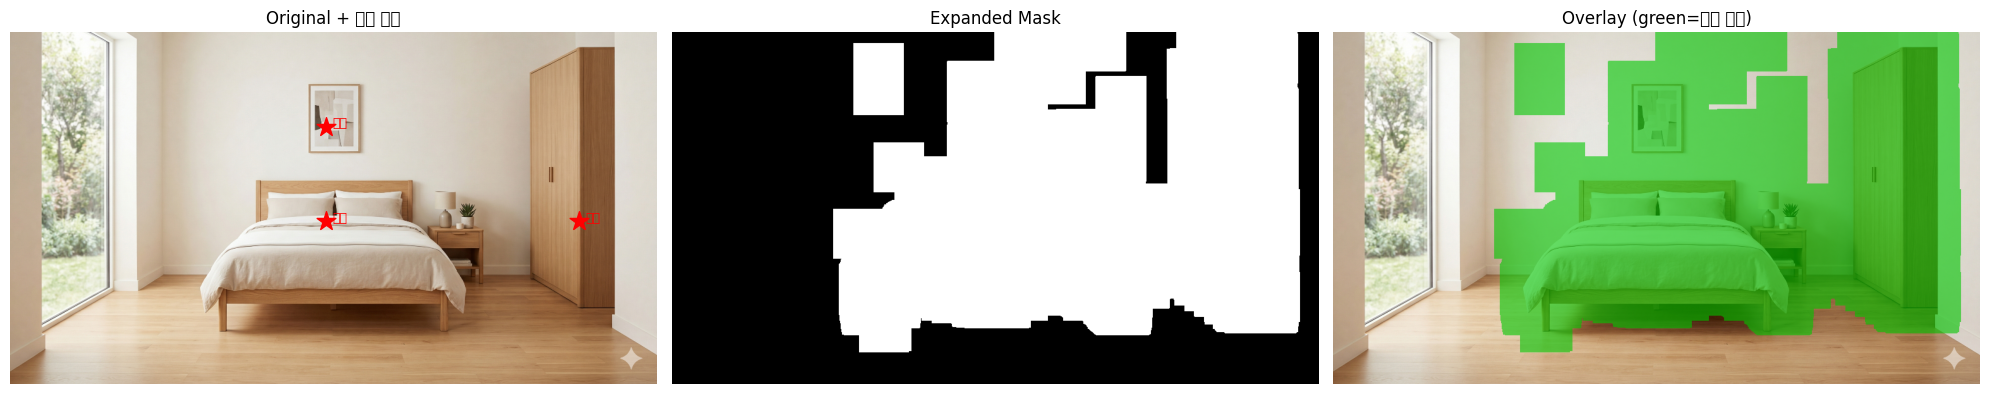

마스크가 가구 전체를 잘 덮으면 셀 5 실행!
부족하면 kernel 크기나 iterations 숫자를 늘려보세요.


In [ ]:
# ============================================================
# 셀 4: SAM2로 마스크 생성
# ============================================================

if not selected_points:
    raise ValueError('⚠️ 셀 3에서 가구를 먼저 추가하세요!')

input_points = np.array(selected_points)
input_labels = np.array([1] * len(selected_points))

print(f'선택된 가구: {list(zip(selected_labels_text, selected_points))}')

USE_MULTI_MASK = len(input_points) == 1

predictor.set_image(image_np)
masks, scores, _ = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=USE_MULTI_MASK,
)

best_idx  = np.argmax(scores)
best_mask = masks[best_idx].astype(bool)

# 마스크 팽창
mask_np = (best_mask * 255).astype(np.uint8)
kernel  = np.ones((40, 40), np.uint8)
mask_np = cv2.dilate(mask_np, kernel, iterations=2)
best_mask_expanded = mask_np > 127

print(f'마스크 점수: {scores}')
print(f'선택: {best_idx}번 (score: {scores[best_idx]:.3f})')

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(image_np)
axes[0].scatter(input_points[:,0], input_points[:,1], c='red', s=200, zorder=5, marker='*')
for (x, y), name in zip(selected_points, selected_labels_text):
    axes[0].text(x+10, y, name, color='red', fontsize=9)
axes[0].set_title('Original + 선택 가구')
axes[0].axis('off')

axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title('Expanded Mask')
axes[1].axis('off')

overlay = image_np.copy().astype(float)
overlay[best_mask_expanded] = overlay[best_mask_expanded] * 0.4 + np.array([0, 200, 0]) * 0.6
axes[2].imshow(overlay.astype(np.uint8))
axes[2].set_title('Overlay (green=제거 영역)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print('마스크가 가구 전체를 잘 덮으면 셀 5 실행!')
print('부족하면 kernel 크기나 iterations 숫자를 늘려보세요.')

🎨 LaMa 인페인팅 실행 중...


/tmp/ipykernel_2998/1104658553.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/1104658553.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/comparison.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


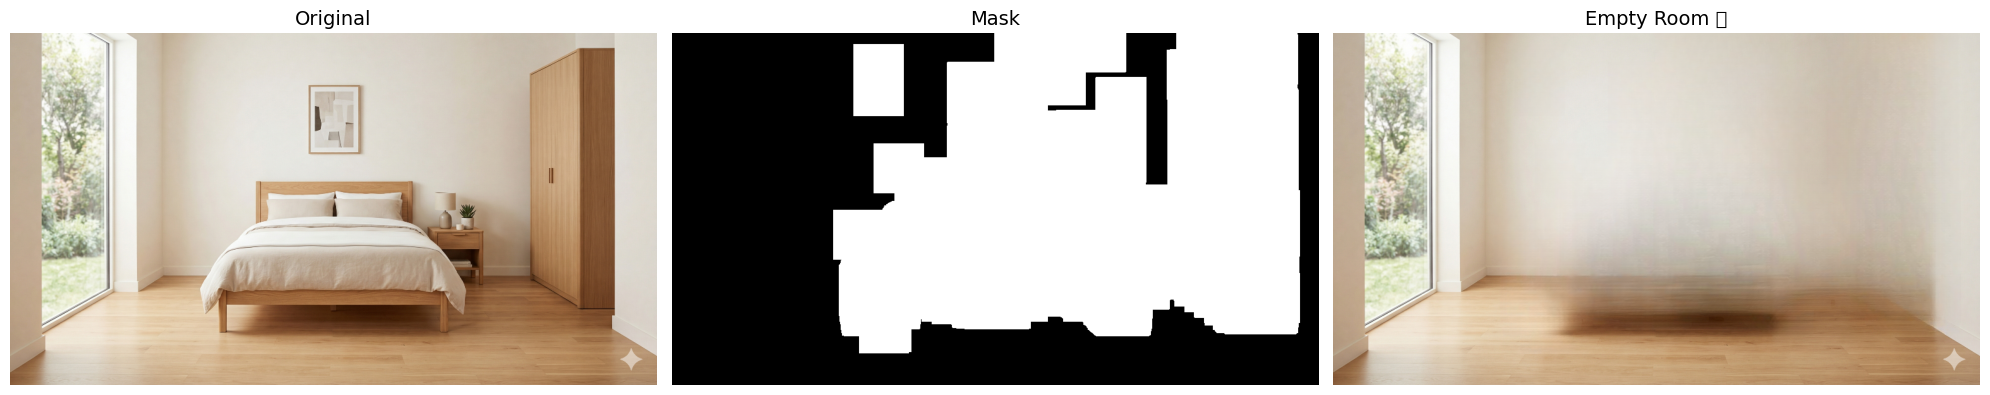

✅ 완료! Drive에 저장됨: /content/drive/MyDrive/furniture_remover/outputs
결과가 맘에 들면 셀 6 실행!


In [ ]:
# ============================================================
# 셀 5: LaMa 인페인팅 (가구 제거)
# ============================================================
import torch

def run_lama(image_np, mask_np):
    # 8의 배수로 패딩
    h, w = image_np.shape[:2]
    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8

    if pad_h > 0 or pad_w > 0:
        image_np = np.pad(image_np, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
        mask_np  = np.pad(mask_np,  ((0, pad_h), (0, pad_w)),          mode='reflect')

    img = image_np.astype(np.float32) / 255.0
    msk = (mask_np > 127).astype(np.float32)
    img_t = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).cuda()
    msk_t = torch.from_numpy(msk).unsqueeze(0).unsqueeze(0).cuda()

    with torch.no_grad():
        batch  = {'image': img_t, 'mask': msk_t}
        batch  = lama_model(batch)
        result = batch['inpainted'][0].permute(1, 2, 0).cpu().numpy()
        result = (result * 255).clip(0, 255).astype(np.uint8)

    # 패딩 제거 (원본 크기로 복원)
    result = result[:h, :w]
    return result

print('🎨 LaMa 인페인팅 실행 중...')
result = run_lama(image_np, mask_np)

# Drive에 저장
OUTPUT_DIR = f'{DRIVE_DIR}/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Image.fromarray(result).save(f'{OUTPUT_DIR}/empty_room.jpg')
Image.fromarray(image_np).save(f'{OUTPUT_DIR}/original.jpg')
Image.fromarray(mask_np).save(f'{OUTPUT_DIR}/mask.png')

# 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(image_np)
axes[0].set_title('Original', fontsize=14)
axes[0].axis('off')
axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title('Mask', fontsize=14)
axes[1].axis('off')
axes[2].imshow(result)
axes[2].set_title('Empty Room ✅', fontsize=14)
axes[2].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparison.png', dpi=150)
plt.show()

print(f'✅ 완료! Drive에 저장됨: {OUTPUT_DIR}')
print('결과가 맘에 들면 셀 6 실행!')

/tmp/ipykernel_2998/1113649317.py:40: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/1113649317.py:40: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/1113649317.py:40: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/1113649317.py:40: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/1113649317.py:40: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/1113649317.py:40: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/1113649317.py:40: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.ti

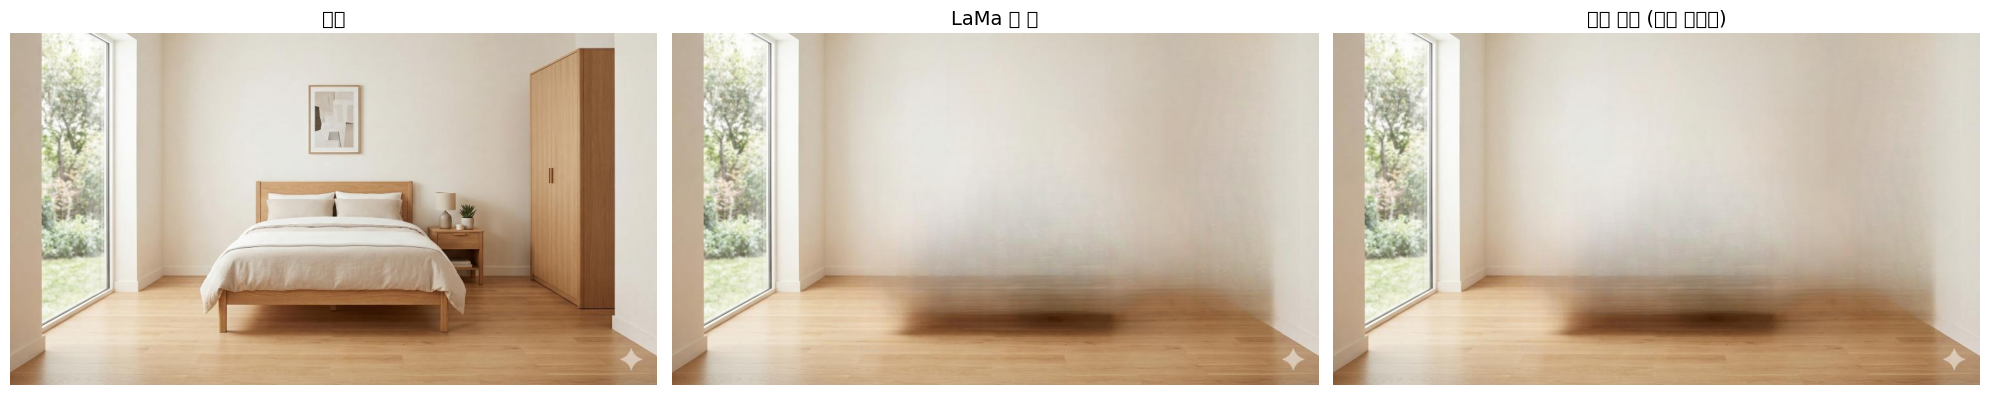

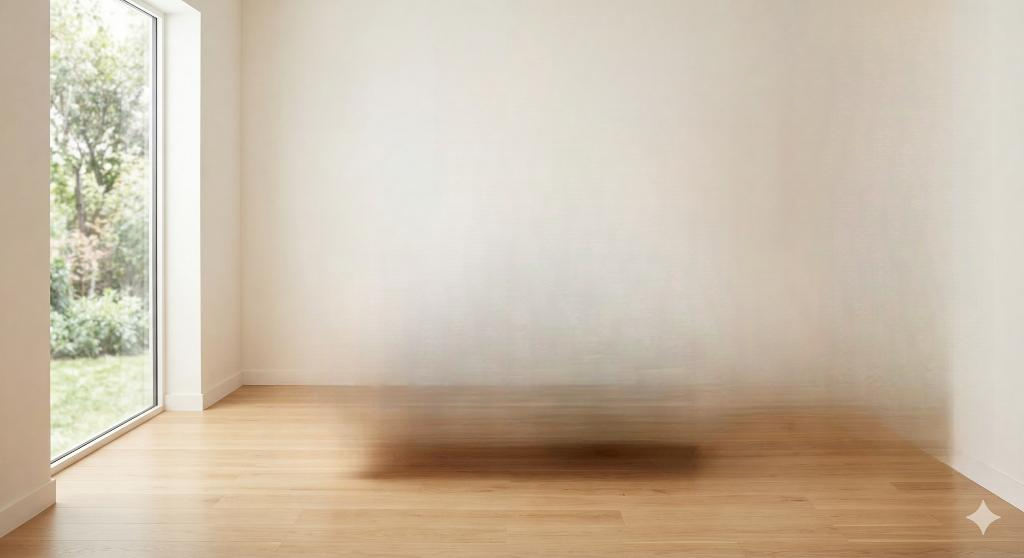

최종 저장 완료: /content/drive/MyDrive/furniture_remover/outputs/final_result.jpg
셀 8 (가구 PNG 추출)로 이동하세요!


In [ ]:
# ============================================================
# 셀 6: Stable Diffusion Inpainting (뿌연 자리 자연스럽게 채우기)
# ============================================================
!pip install -q diffusers transformers accelerate

from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 모델 로드
print('🤖 SD Inpainting 모델 로드 중... (최초 1~2분)')
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")
print('✅ 모델 로드 완료!')

# 이미지 & 마스크 로드 (셀 5 결과물 사용)
OUTPUT_DIR = f'{DRIVE_DIR}/outputs'
image_pil = Image.open(f'{OUTPUT_DIR}/empty_room.jpg').convert('RGB')
mask_pil  = Image.open(f'{OUTPUT_DIR}/mask.png').convert('L')

# 8의 배수로 리사이즈 (SD 필수 조건)
W, H = image_pil.size
new_w = (W // 8) * 8
new_h = (H // 8) * 8
image_pil = image_pil.resize((new_w, new_h))
mask_pil  = mask_pil.resize((new_w, new_h))

# 마스크 살짝 팽창 (경계 자연스럽게)
mask_np = np.array(mask_pil)
kernel  = np.ones((20, 20), np.uint8)
mask_np = cv2.dilate(mask_np, kernel, iterations=1)

⚠️ Canny ControlNet 로드 중 (최초 1회 시간 소요)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_inpaint.StableDiffusionControlNetInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or

✅ Canny 파이프라인 로드 완료!
📐 윤곽선(Canny Edge) 추출 중...
🎨 평면을 유지하며 고화질 텍스처 복원 중...


  0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipykernel_2998/3102891352.py:99: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3102891352.py:99: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3102891352.py:99: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3102891352.py:99: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3102891352.py:99: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3102891352.py:99: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3102891352.py:99: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_lay

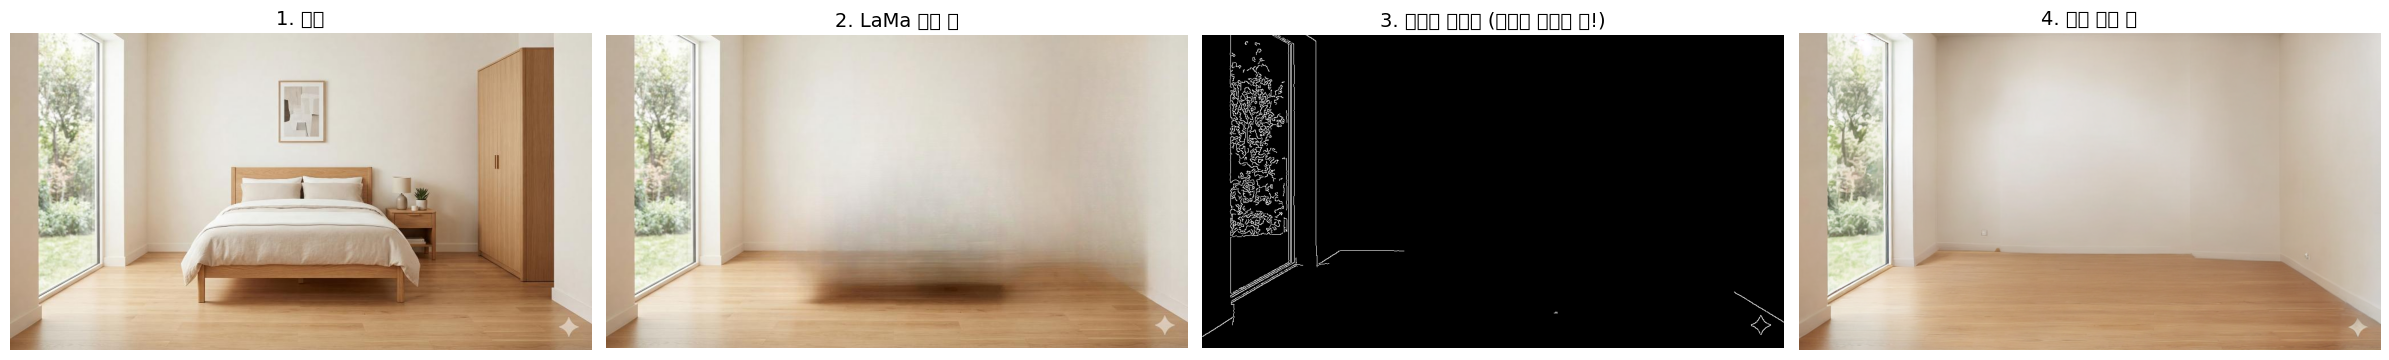

📸 최종 결과:


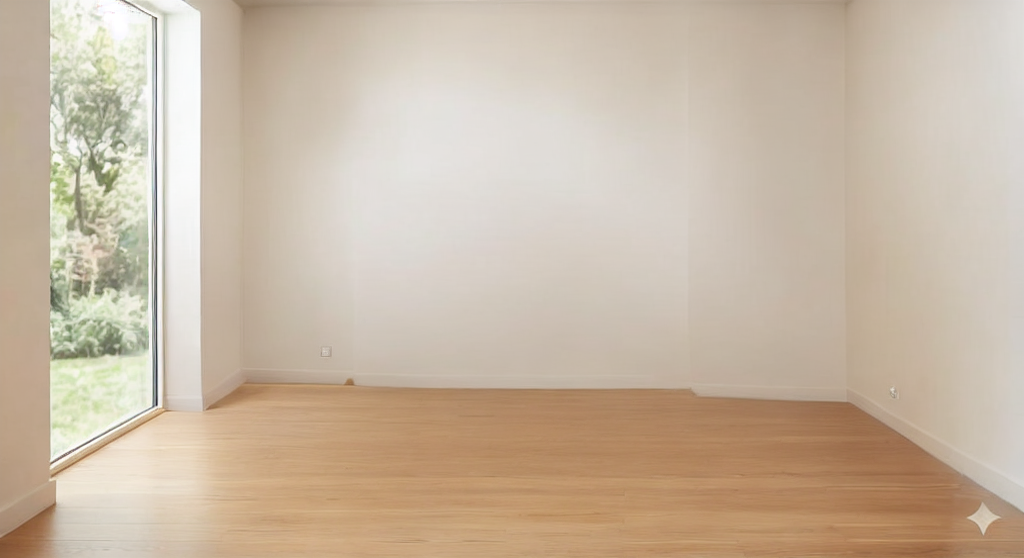

In [ ]:
# ==========================================
# 셀 7: Canny ControlNet + Inpainting (빈 공간 완벽 생성)
# ==========================================
from diffusers import StableDiffusionControlNetInpaintPipeline, ControlNetModel, DDIMScheduler
import torch
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display
import os
import gc

# 이전 모델 메모리 초기화 (OOM 방지)
torch.cuda.empty_cache()
gc.collect()

OUTPUT_DIR = f'{DRIVE_DIR}/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Canny ControlNet 및 파이프라인 로드 (Depth 대신 Canny 사용)
if 'pipe_canny' not in dir():
    print('⚠️ Canny ControlNet 로드 중 (최초 1회 시간 소요)...')
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/control_v11p_sd15_canny", # 🔥 Depth -> Canny로 교체
        torch_dtype=torch.float16
    )
    pipe_canny = StableDiffusionControlNetInpaintPipeline.from_pretrained(
        "runwayml/stable-diffusion-inpainting",
        controlnet=controlnet,
        torch_dtype=torch.float16,
        safety_checker=None
    ).to("cuda")
    pipe_canny.scheduler = DDIMScheduler.from_config(pipe_canny.scheduler.config)
    print('✅ Canny 파이프라인 로드 완료!')

# 2. 이미지 및 마스크 준비
image_pil = Image.open(f'{OUTPUT_DIR}/empty_room.jpg').convert('RGB')
mask_pil  = Image.open(f'{OUTPUT_DIR}/mask.png').convert('L')

W, H = image_pil.size
new_w, new_h = (W // 8) * 8, (H // 8) * 8
image_pil = image_pil.resize((new_w, new_h))
mask_pil  = mask_pil.resize((new_w, new_h))

# 마스크 팽창 극대화 (그림자 완벽 커버)
mask_np = np.array(mask_pil)
mask_np = cv2.dilate(mask_np, np.ones((41, 41), np.uint8), iterations=2)
kernel_down = np.zeros((40, 40), np.uint8)
kernel_down[20:, :] = 1
mask_np = cv2.dilate(mask_np, kernel_down, iterations=3)
mask_np = cv2.GaussianBlur(mask_np, (51, 51), 0)
mask_pil = Image.fromarray(mask_np)

# 3. 🔥 핵심: Canny (윤곽선) 추출
# LaMa가 뭉갠 곳은 윤곽선이 없어서 완벽한 까만색(빈 공간)으로 나옵니다.
print('📐 윤곽선(Canny Edge) 추출 중...')
image_cv = np.array(image_pil)
# Canny 임계값 설정 (세밀한 선 추출)
edges = cv2.Canny(image_cv, 100, 200)
edges_3c = np.stack([edges]*3, axis=-1)
canny_pil = Image.fromarray(edges_3c)

# 4. 빈 공간 채우기
print('🎨 평면을 유지하며 고화질 텍스처 복원 중...')
result = pipe_canny(
    prompt="empty room, continuous seamless wooden floor, clean flat white wall, photorealistic textures",
    negative_prompt="furniture, bed, chair, table, objects, 3d render, shadows, clutter, lines, bumps",
    image=image_pil,
    mask_image=mask_pil,
    control_image=canny_pil, # 🔥 윤곽선 맵 주입 (선이 없으니 물체도 못 그림)
    num_inference_steps=50,
    guidance_scale=8.0,
    controlnet_conditioning_scale=1.0,
    strength=0.8, # 화질을 높이기 위해 강도를 강하게 유지
).images[0]

result = result.resize((W, H), Image.LANCZOS)
result.save(f'{OUTPUT_DIR}/final_result.jpg')

# 5. 결과 시각화
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(np.array(Image.open(f'{OUTPUT_DIR}/original.jpg')))
axes[0].set_title('1. 원본', fontsize=14)
axes[0].axis('off')

axes[1].imshow(np.array(image_pil))
axes[1].set_title('2. LaMa 제거 후', fontsize=14)
axes[1].axis('off')

axes[2].imshow(np.array(canny_pil))
axes[2].set_title('3. 추출된 윤곽선 (이곳이 비어야 함!)', fontsize=14)
axes[2].axis('off')

axes[3].imshow(np.array(result))
axes[3].set_title('4. 최종 결과 ✅', fontsize=14)
axes[3].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/final_comparison.png', dpi=150)
plt.show()

print('📸 최종 결과:')
display(result)

총 3개 가구 추출 시작...

[1/3] 침대 처리 중...
  ✅ 침대.png 저장 (score: 0.844)
[2/3] 옷장 처리 중...
  ✅ 옷장.png 저장 (score: 0.955)
[3/3] 액자 처리 중...
  ✅ 액자.png 저장 (score: 0.531)


/tmp/ipykernel_2998/3678685362.py:155: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3678685362.py:155: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3678685362.py:155: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3678685362.py:155: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3678685362.py:155: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3678685362.py:155: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2998/3678685362.py:155: UserWarning: Glyph 52840 (\N{HANGUL SYLLABLE CIM}) missing from font(s) DejaVu Sans.
  plt

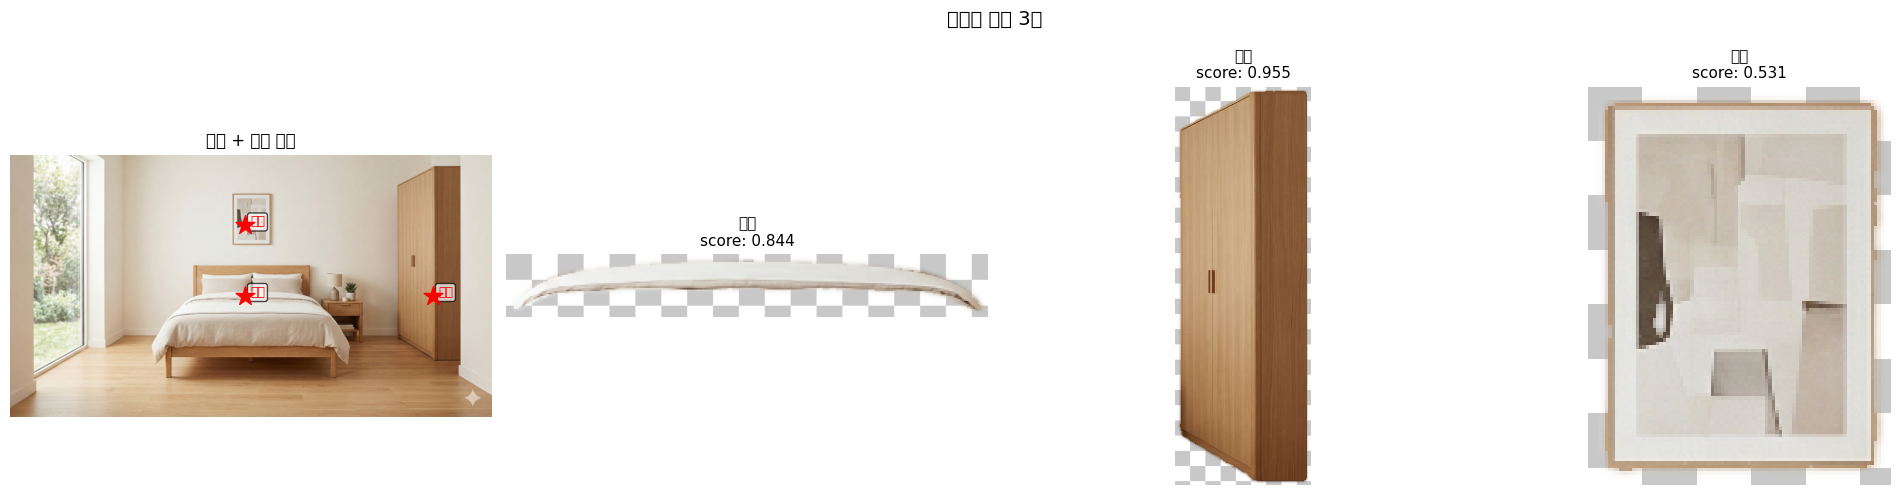


📦 저장 완료:
  - 침대.png (score: 0.844)
  - 옷장.png (score: 0.955)
  - 액자.png (score: 0.531)

셀 9에서 각 가구를 개별 배치하세요!


In [22]:
# ============================================================
# 셀 8: 가구 정밀 추출 (배경 제거 개선)
# ============================================================
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

LIBRARY_DIR = f'{DRIVE_DIR}/furniture_library'
os.makedirs(LIBRARY_DIR, exist_ok=True)

def refine_mask(mask_np, edge_blur=3):
    """
    SAM2 마스크 정제:
    - dilate 제거 (배경 유입 방지)
    - 경계만 가우시안 블러로 부드럽게
    """
    # 작은 노이즈 제거 (erode → dilate)
    kernel_small = np.ones((3, 3), np.uint8)
    mask_clean = cv2.morphologyEx(mask_np, cv2.MORPH_OPEN, kernel_small)

    # 경계 부드럽게 (가우시안 블러를 알파값에만 적용)
    mask_float = mask_clean.astype(np.float32) / 255.0
    blur_size  = edge_blur * 2 + 1
    mask_blur  = cv2.GaussianBlur(mask_float, (blur_size, blur_size), 0)

    # 내부는 완전 불투명, 경계만 블렌딩
    inner = (mask_clean > 200).astype(np.float32)
    alpha = np.maximum(inner, mask_blur)

    return (alpha * 255).astype(np.uint8)

def extract_furniture(image_np, mask_np):
    """정제된 마스크로 가구만 RGBA 추출"""
    h_img, w_img = image_np.shape[:2]
    if mask_np.shape != (h_img, w_img):
        mask_np = cv2.resize(mask_np, (w_img, h_img), interpolation=cv2.INTER_NEAREST)

    binary = mask_np > 127
    if not np.any(binary):
        return None, None

    # RGBA 생성 (알파 = 정제된 마스크값 그대로)
    rgba = np.zeros((h_img, w_img, 4), dtype=np.uint8)
    rgba[..., :3] = image_np
    rgba[..., 3]  = mask_np   # 0~255 그라데이션 알파

    # bounding box (여백 최소화)
    rows = np.any(binary, axis=1)
    cols = np.any(binary, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    pad  = 5   # 여백 최소화 (기존 10 → 5)
    rmin = max(0, rmin - pad)
    rmax = min(h_img, rmax + pad)
    cmin = max(0, cmin - pad)
    cmax = min(w_img, cmax + pad)

    cropped = rgba[rmin:rmax, cmin:cmax]
    return Image.fromarray(cropped), (rmin, rmax, cmin, cmax)

# ── 가구별 개별 마스크 생성 & 저장 ───────────────────────
if not selected_points:
    raise ValueError('⚠ 셀 3에서 가구를 먼저 선택하세요!')

saved_furniture = []
print(f'총 {len(selected_points)}개 가구 추출 시작...\n')

for idx, (point, label) in enumerate(zip(selected_points, selected_labels_text)):
    print(f'[{idx+1}/{len(selected_points)}] {label} 처리 중...')

    predictor.set_image(image_np)
    masks, scores, _ = predictor.predict(
        point_coords=np.array([point]),
        point_labels=np.array([1]),
        multimask_output=True,
    )

    best_mask = masks[np.argmax(scores)].astype(bool)

    h_img, w_img = image_np.shape[:2]
    if best_mask.shape != (h_img, w_img):
        best_mask = cv2.resize(
            best_mask.astype(np.uint8),
            (w_img, h_img),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool)

    # dilate 없이 정밀 정제만 적용
    mask_raw     = (best_mask * 255).astype(np.uint8)
    mask_refined = refine_mask(mask_raw, edge_blur=3)

    furniture_img, bbox = extract_furniture(image_np, mask_refined)
    if furniture_img is None:
        print(f'  ⚠ {label}: 마스크가 비어있어 스킵')
        continue

    name_safe  = label.replace(' ', '_')
    existing   = [f for f in os.listdir(LIBRARY_DIR) if f.startswith(name_safe)]
    if existing:
        name_safe = f'{name_safe}_{len(existing)}'

    save_path = f'{LIBRARY_DIR}/{name_safe}.png'
    furniture_img.save(save_path)

    saved_furniture.append({
        'name':  label,
        'file':  f'{name_safe}.png',
        'bbox':  bbox,
        'score': float(scores[np.argmax(scores)]),
    })
    print(f'  ✅ {name_safe}.png 저장 (score: {scores[np.argmax(scores)]:.3f})')

# ── 결과 시각화 ───────────────────────────────────────────
n = len(saved_furniture)
if n > 0:
    cols = min(n + 1, 4)
    rows = -(-( n + 1) // cols)   # ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).flatten()

    axes[0].imshow(image_np)
    for (x, y), name in zip(selected_points, selected_labels_text):
        axes[0].scatter(x, y, c='red', s=200, zorder=5, marker='*')
        axes[0].text(x+10, y, name, color='red', fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
    axes[0].set_title('원본 + 선택 가구', fontsize=12)
    axes[0].axis('off')

    for i, info in enumerate(saved_furniture):
        ax = axes[i + 1]
        furn_img = Image.open(f'{LIBRARY_DIR}/{info["file"]}')
        fw, fh   = furn_img.size

        # 체커보드 배경
        checker = np.zeros((fh, fw, 3), dtype=np.uint8)
        for r in range(fh):
            for c in range(fw):
                checker[r, c] = [200,200,200] if (r//16 + c//16) % 2 == 0 else [255,255,255]
        fa    = np.array(furn_img)
        alpha = fa[..., 3:4] / 255.0
        prev  = (fa[..., :3] * alpha + checker * (1 - alpha)).astype(np.uint8)

        ax.imshow(prev)
        ax.set_title(f'{info["name"]}\nscore: {info["score"]:.3f}', fontsize=11)
        ax.axis('off')

    for j in range(n + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'추출된 가구 {n}개', fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f'\n📦 저장 완료:')
    for info in saved_furniture:
        print(f'  - {info["file"]} (score: {info["score"]:.3f})')
    print('\n셀 9에서 각 가구를 개별 배치하세요!')

In [ ]:
!rm -rf /root/.cache/torch/hub/isl-org_ZoeDepth_main
!rm -rf /root/.cache/torch/hub/checkpoints/*

In [ ]:
import shutil
shutil.rmtree('/root/.cache/torch/hub', ignore_errors=True)

In [ ]:
# ============================================================
# 셀 9: 재배치 UI (ZoeDepth + 원근감 + 누적 합성)
# ============================================================
from google.colab import files
from IPython.display import display, clear_output
import ipywidgets as widgets
import io, cv2, os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

# ── ZoeDepth 설치 및 로드 (최초 1회) ─────────────────────
if 'depth_model' not in dir():
    print('📦 ZoeDepth 설치 중...')
    # 🔥 중요: timm 버전 고정
    os.system('pip install -q timm==0.6.13')
    # 수정
    os.system('pip install -q git+https://github.com/isl-org/ZoeDepth.git@v1.0')

    # 손상된 캐시 제거
    import shutil
    shutil.rmtree('/root/.cache/torch/hub', ignore_errors=True)
    cache_dir = '/root/.cache/torch/hub'
    for item in ['main.zip', 'master.zip', 'checkpoints/ZoeD_M12_NK.pt']:
        path = f'{cache_dir}/{item}'
        if os.path.exists(path):
            os.remove(path)
            print(f'  🗑 캐시 삭제: {item}')

    # ZoeDepth 체크포인트 직접 다운로드 (wget으로 안정적으로)
    ckpt_dir = f'{cache_dir}/checkpoints'
    ckpt_path = f'{ckpt_dir}/ZoeD_M12_NK.pt'
    os.makedirs(ckpt_dir, exist_ok=True)

    if not os.path.exists(ckpt_path):
        print('⬇️ ZoeDepth 체크포인트 다운로드 중...')
        os.system(
            f'wget -q --show-progress '
            f'https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_NK.pt '
            f'-O {ckpt_path}'
        )
        # 다운로드 검증
        size = os.path.getsize(ckpt_path) / 1024 / 1024
        if size < 100:
            raise RuntimeError(f'❌ 다운로드 실패 (파일 크기: {size:.1f}MB — 너무 작음)')
        print(f'✅ 체크포인트 다운로드 완료 ({size:.0f}MB)')

    print('🔄 ZoeDepth 모델 로드 중...')
    depth_model = torch.hub.load(
    'isl-org/ZoeDepth',
    'ZoeD_K',   # 🔥 NK → K로 변경
    pretrained=True,
    trust_repo=True
).to('cuda').eval()
    print('✅ ZoeDepth 로드 완료!')

def get_depth_map(image_np):
    """이미지에서 깊이 맵 추출 (0=가까움, 1=멀리)"""
    img_pil = Image.fromarray(image_np)
    with torch.no_grad():
        depth = depth_model.infer_pil(img_pil)
    depth_np = np.array(depth)
    # 정규화 (0~1)
    d_min, d_max = depth_np.min(), depth_np.max()
    depth_norm = (depth_np - d_min) / (d_max - d_min + 1e-8)
    return depth_norm

def get_depth_at_point(depth_map, px, py):
    """특정 좌표의 깊이값 반환"""
    h, w = depth_map.shape
    px = np.clip(px, 0, w-1)
    py = np.clip(py, 0, h-1)
    # 주변 10px 평균으로 안정적인 값 추출
    x0, x1 = max(0, px-10), min(w, px+10)
    y0, y1 = max(0, py-10), min(h, py+10)
    return float(depth_map[y0:y1, x0:x1].mean())

def auto_scale_by_depth(furniture_img, depth_val, base_scale=1.0):
    """
    깊이값 기반 자동 크기 조정
    depth_val 0 = 가장 가까움 (크게)
    depth_val 1 = 가장 멀리 (작게)
    """
    # 깊이 0.5 기준으로 ±50% 크기 조정
    depth_factor = 1.5 - depth_val   # 가까울수록 크게
    return base_scale * depth_factor

def perspective_transform(img_pil, angle_h=0, angle_v=0):
    """
    수평/수직 각도 시뮬레이션 (perspective warp)
    angle_h: -30 ~ 30 (좌우 회전감)
    angle_v: -20 ~ 20 (위아래 기울기)
    """
    img_np = np.array(img_pil)
    h, w   = img_np.shape[:2]

    # 각도를 warp 강도로 변환
    warp_h = int(w * angle_h / 100)
    warp_v = int(h * angle_v / 100)

    # 원본 4점 → 변환 4점
    src = np.float32([
        [0,   0  ],
        [w-1, 0  ],
        [w-1, h-1],
        [0,   h-1]
    ])
    dst = np.float32([
        [max(0, -warp_h),      max(0, -warp_v)     ],
        [w-1 - max(0, warp_h), max(0,  warp_v)     ],
        [w-1 - max(0, warp_h), h-1 - max(0, warp_v)],
        [max(0, -warp_h),      h-1 + max(0, warp_v)]
    ])

    M = cv2.getPerspectiveTransform(src, dst)

    # RGBA 채널 분리 처리
    if img_np.shape[2] == 4:
        rgb   = cv2.warpPerspective(img_np[...,:3], M, (w, h),
                                    flags=cv2.INTER_LINEAR,
                                    borderMode=cv2.BORDER_CONSTANT)
        alpha = cv2.warpPerspective(img_np[...,3],  M, (w, h),
                                    flags=cv2.INTER_LINEAR,
                                    borderMode=cv2.BORDER_CONSTANT)
        result = np.dstack([rgb, alpha])
    else:
        result = cv2.warpPerspective(img_np, M, (w, h))

    return Image.fromarray(result)

# ── 타겟 이미지 업로드 (최초 1회) ────────────────────────
if 'target_np_original' not in dir():
    print('📁 가구를 배치할 방 사진을 업로드하세요!')
    uploaded_target = files.upload()
    filename_t = list(uploaded_target.keys())[0]
    target_img = Image.open(io.BytesIO(uploaded_target[filename_t])).convert('RGB')
    target_np_original = np.array(target_img)

    MAX_SIZE = 1024
    h, w = target_np_original.shape[:2]
    if max(h, w) > MAX_SIZE:
        scale = MAX_SIZE / max(h, w)
        target_np_original = cv2.resize(
            target_np_original, (int(w*scale), int(h*scale))
        )

    print('🔄 타겟 이미지 깊이 맵 추출 중...')
    target_depth = get_depth_map(target_np_original)
    print(f'✅ 타겟 이미지 로드 완료: '
          f'{target_np_original.shape[1]}x{target_np_original.shape[0]}')

    # 깊이 맵 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(target_np_original)
    axes[0].set_title('타겟 이미지')
    axes[0].axis('off')
    axes[1].imshow(target_depth, cmap='plasma')
    axes[1].set_title('깊이 맵 (밝을수록 가까움)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# 누적 캔버스 초기화
if 'canvas_np' not in dir():
    canvas_np = target_np_original.copy()

h, w = canvas_np.shape[:2]

# ── 라이브러리 로드 ───────────────────────────────────────
library_files = sorted([f for f in os.listdir(LIBRARY_DIR) if f.endswith('.png')])
if not library_files:
    raise ValueError('⚠ 가구 라이브러리가 비어있습니다. 셀 8을 먼저 실행하세요!')

# ── UI 구성 ───────────────────────────────────────────────
style  = {'description_width': '150px'}
layout = widgets.Layout(width='540px')

furniture_select = widgets.Dropdown(
    options=library_files,
    description='🪑 가구 선택:',
    style=style, layout=widgets.Layout(width='420px')
)

# 깊이 기반 자동 크기 조정 토글
auto_scale_toggle = widgets.Checkbox(
    value=True,
    description='📐 깊이 기반 크기 자동 조정',
    style=style
)

manual_scale = widgets.FloatSlider(
    value=1.0, min=0.1, max=3.0, step=0.05,
    description='📐 크기 배율 (수동):',
    style=style, layout=layout, readout_format='.2f'
)

pos_x_slider = widgets.IntSlider(
    value=w//2, min=0, max=w-1, step=5,
    description='📍 X 위치:',
    style=style, layout=layout
)
pos_y_slider = widgets.IntSlider(
    value=h//2, min=0, max=h-1, step=5,
    description='📍 Y 위치:',
    style=style, layout=layout
)

angle_h_slider = widgets.IntSlider(
    value=0, min=-30, max=30, step=1,
    description='↔ 수평 각도:',
    style=style, layout=layout
)
angle_v_slider = widgets.IntSlider(
    value=0, min=-20, max=20, step=1,
    description='↕ 수직 각도:',
    style=style, layout=layout
)

flip_toggle = widgets.Checkbox(
    value=False, description='↔ 좌우 반전', style=style
)

preview_btn = widgets.Button(description='👁 미리보기',         button_style='info')
place_btn   = widgets.Button(description='✅ 배치 확정',         button_style='success')
undo_btn    = widgets.Button(description='↩ 마지막 취소',        button_style='warning')
reset_btn   = widgets.Button(description='🗑 전체 초기화',       button_style='danger')
output_area = widgets.Output()

placement_history = []
placement_state   = {}

def build_furniture(furn_file, px, py, use_auto_scale, m_scale, angle_h, angle_v, flip):
    """가구 이미지 변환 (원근감 + 크기 조정)"""
    furn = Image.open(f'{LIBRARY_DIR}/{furn_file}').convert('RGBA')

    # 좌우 반전
    if flip:
        furn = furn.transpose(Image.FLIP_LEFT_RIGHT)

    # 수평/수직 각도 적용
    if angle_h != 0 or angle_v != 0:
        furn = perspective_transform(furn, angle_h, angle_v)

    # 크기 결정
    if use_auto_scale:
        depth_val  = get_depth_at_point(target_depth, px, py)
        auto_s     = auto_scale_by_depth(furn, depth_val, base_scale=m_scale)
        final_scale = auto_s
        depth_info  = f'깊이: {depth_val:.2f} → 배율: {final_scale:.2f}'
    else:
        final_scale = m_scale
        depth_info  = f'수동 배율: {final_scale:.2f}'

    fw = max(1, int(furn.width  * final_scale))
    fh = max(1, int(furn.height * final_scale))
    furn = furn.resize((fw, fh), Image.LANCZOS)

    return furn, final_scale, depth_info

def composite(base_np, furn_pil, px, py):
    """가구를 캔버스에 합성"""
    fw, fh = furn_pil.size
    x0, y0 = px - fw//2, py - fh//2
    result  = Image.fromarray(base_np).convert('RGBA')
    result.paste(furn_pil, (x0, y0), furn_pil)
    return np.array(result.convert('RGB')), (x0, y0, fw, fh)

def on_preview(b):
    with output_area:
        clear_output(wait=True)
        px, py = pos_x_slider.value, pos_y_slider.value

        furn_pil, scale, depth_info = build_furniture(
            furniture_select.value, px, py,
            auto_scale_toggle.value, manual_scale.value,
            angle_h_slider.value, angle_v_slider.value,
            flip_toggle.value
        )
        preview_np, bbox = composite(canvas_np, furn_pil, px, py)

        placement_state.update({
            'preview':    preview_np,
            'bbox':       bbox,
            'furn_pil':   furn_pil,
            'file':       furniture_select.value,
            'pos':        (px, py),
        })

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        axes[0].imshow(canvas_np)
        axes[0].set_title('현재 캔버스')
        axes[0].axis('off')

        axes[1].imshow(preview_np)
        x0, y0, fw, fh = bbox
        import matplotlib.patches as patches
        axes[1].add_patch(patches.Rectangle(
            (x0, y0), fw, fh,
            linewidth=1.5, edgecolor='lime',
            facecolor='none', linestyle='--'
        ))
        axes[1].set_title(f'미리보기 | {depth_info}')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()
        print('마음에 들면 [✅ 배치 확정]을 누르세요!')

def on_place(b):
    global canvas_np
    with output_area:
        clear_output(wait=True)
        if not placement_state:
            print('⚠ 먼저 미리보기를 실행하세요!')
            return

        placement_history.append(canvas_np.copy())
        canvas_np, _ = composite(
            canvas_np,
            placement_state['furn_pil'],
            placement_state['pos'][0],
            placement_state['pos'][1],
        )
        print(f'✅ [{placement_state["file"]}] 배치 완료! '
              f'(총 {len(placement_history)}개)')

        plt.figure(figsize=(10, 7))
        plt.imshow(canvas_np)
        plt.title(f'현재 캔버스 ({len(placement_history)}개 배치)')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        print('다음 가구를 선택하거나 셀 10에서 후보정을 실행하세요!')

def on_undo(b):
    global canvas_np
    with output_area:
        clear_output(wait=True)
        if not placement_history:
            print('⚠ 되돌릴 배치가 없습니다.')
            return
        canvas_np = placement_history.pop()
        print(f'↩ 취소 완료. (남은 배치: {len(placement_history)}개)')
        plt.figure(figsize=(10, 7))
        plt.imshow(canvas_np)
        plt.title(f'현재 캔버스 ({len(placement_history)}개 배치)')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

def on_reset(b):
    global canvas_np
    with output_area:
        clear_output(wait=True)
        canvas_np = target_np_original.copy()
        placement_history.clear()
        placement_state.clear()
        print('🗑 전체 초기화 완료.')

preview_btn.on_click(on_preview)
place_btn.on_click(on_place)
undo_btn.on_click(on_undo)
reset_btn.on_click(on_reset)

display(widgets.VBox([
    widgets.HTML('<b>🪑 가구 재배치 설정</b>'),
    furniture_select,
    widgets.HTML('<b>📐 크기</b>'),
    auto_scale_toggle,
    manual_scale,
    widgets.HTML('<b>📍 위치</b>'),
    pos_x_slider,
    pos_y_slider,
    widgets.HTML('<b>🔄 각도/원근감</b>'),
    angle_h_slider,
    angle_v_slider,
    flip_toggle,
    widgets.HBox([preview_btn, place_btn]),
    widgets.HBox([undo_btn, reset_btn]),
    output_area,
]))

✅ 1개 배치 감지 → 후보정 시작
💡 추정된 조명 방향: x=-0.24, y=-0.37
🌑 그림자 생성 중...
✅ 그림자 생성 완료!
🎨 Poisson Blending 중...
✅ Poisson Blending 완료!
📦 ControlNet 설치 중...
🎨 ControlNet 깊이 기반 경계 보정 중...


  0%|          | 0/20 [00:00<?, ?it/s]

✅ 저장 완료: /content/drive/MyDrive/furniture_remover/outputs


/tmp/ipykernel_25653/2792844370.py:225: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25653/2792844370.py:225: UserWarning: Glyph 44191 (\N{HANGUL SYLLABLE GES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25653/2792844370.py:225: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25653/2792844370.py:225: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25653/2792844370.py:225: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25653/2792844370.py:225: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25653/2792844370.py:225: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu San

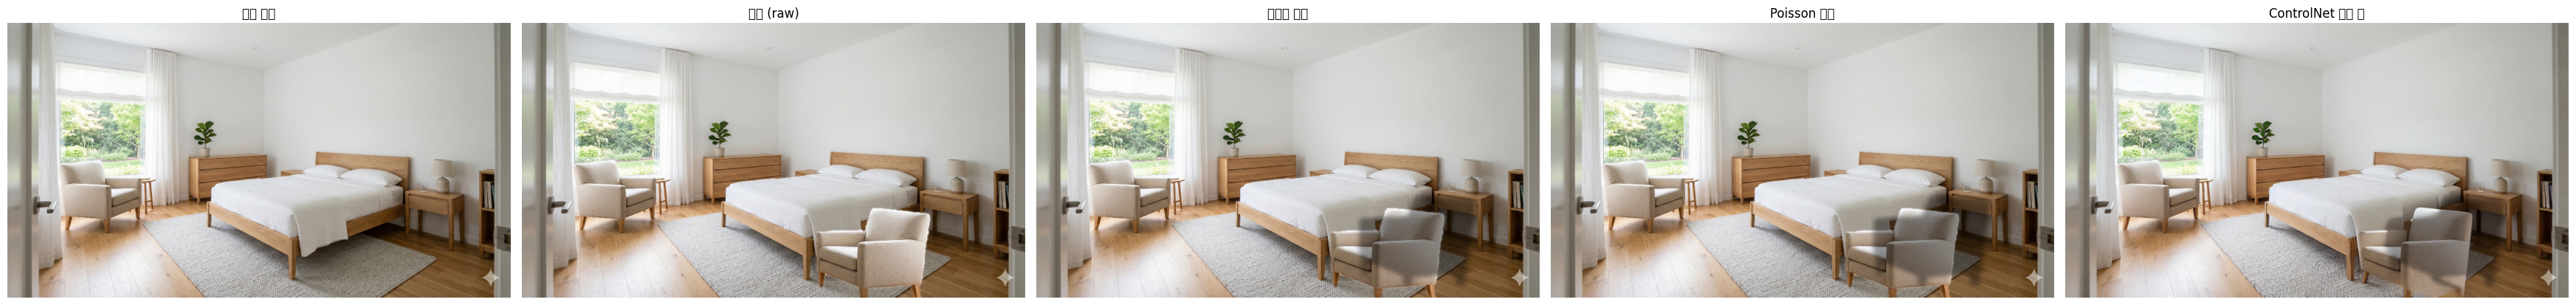

🎉 고품질 후보정 완료!


In [ ]:
# ============================================================
# 셀 10: 그림자 생성 + ControlNet + SD 후보정
# ============================================================
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch, os

# ── 상태 확인 ─────────────────────────────────────────────
if 'canvas_np' not in dir() or not placement_history:
    raise ValueError('⚠ 셀 9에서 [✅ 배치 확정]을 먼저 누르세요!')

print(f'✅ {len(placement_history)}개 배치 감지 → 후보정 시작')

# ── Step 1: 그림자 자동 생성 ──────────────────────────────
def estimate_light_direction(image_np):
    """
    이미지 밝기 분포로 조명 방향 추정
    반환: (light_x, light_y) -1~1 범위
    """
    gray  = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY).astype(float)
    h, w  = gray.shape
    # 좌우/상하 밝기 차이로 방향 추정
    left  = gray[:, :w//2].mean()
    right = gray[:, w//2:].mean()
    top   = gray[:h//2, :].mean()
    bot   = gray[h//2:, :].mean()
    light_x = (right - left) / 128.0   # 오른쪽이 밝으면 빛이 오른쪽에서
    light_y = (bot - top)   / 128.0
    return np.clip(light_x, -1, 1), np.clip(light_y, -1, 1)

def generate_shadow(canvas_np, target_np, furn_mask, light_x, light_y,
                    shadow_len=0.3, shadow_opacity=0.45, blur_r=21):
    """
    가구 마스크 기반 그림자 생성
    - light_x, light_y: 조명 방향
    - shadow_len: 그림자 길이 (0~1)
    - shadow_opacity: 그림자 진하기
    """
    h, w = furn_mask.shape

    # 그림자 오프셋 (조명 반대 방향)
    offset_x = int(-light_x * w * shadow_len)
    offset_y = int( light_y * h * shadow_len * 0.5)  # 바닥 투영

    # 마스크 이동
    M = np.float32([[1, 0, offset_x], [0, 1, offset_y]])
    shadow_mask = cv2.warpAffine(
        furn_mask, M, (w, h),
        borderMode=cv2.BORDER_CONSTANT, borderValue=0
    )

    # 아래로 갈수록 퍼지는 효과 (원근 그림자)
    for i in range(h):
        spread = max(1, int(i / h * blur_r))
        if spread % 2 == 0:
            spread += 1
        shadow_mask[i] = cv2.GaussianBlur(
            shadow_mask[i:i+1], (spread, 1), 0
        )[0]

    # 전체 블러
    shadow_mask = cv2.GaussianBlur(shadow_mask, (blur_r, blur_r), 0)

    # 그림자 합성
    result = canvas_np.astype(float).copy()
    shadow_alpha = (shadow_mask / 255.0) * shadow_opacity
    for c in range(3):
        result[..., c] = result[..., c] * (1 - shadow_alpha)

    return np.clip(result, 0, 255).astype(np.uint8)

# 변경 영역 마스크 추출
diff     = np.abs(canvas_np.astype(int) - target_np_original.astype(int))
furn_mask = ((diff.sum(axis=2) > 15) * 255).astype(np.uint8)

# 노이즈 제거
kernel    = np.ones((5, 5), np.uint8)
furn_mask = cv2.morphologyEx(furn_mask, cv2.MORPH_CLOSE, kernel)

# 조명 방향 추정
light_x, light_y = estimate_light_direction(target_np_original)
print(f'💡 추정된 조명 방향: x={light_x:.2f}, y={light_y:.2f}')

# 그림자 생성
print('🌑 그림자 생성 중...')
shadow_result = generate_shadow(
    canvas_np, target_np_original, furn_mask,
    light_x, light_y,
    shadow_len=0.25,
    shadow_opacity=0.4,
    blur_r=25
)
print('✅ 그림자 생성 완료!')

# ── Step 2: Poisson Blending ──────────────────────────────
def poisson_blend(target_np, canvas_np, mask):
    """색감/조명 자연스럽게 통합"""
    kernel  = np.ones((5, 5), np.uint8)
    mask_e  = cv2.erode(mask, kernel, iterations=2)
    if mask_e.max() == 0:
        return canvas_np.copy()

    contours, _ = cv2.findContours(
        mask_e, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return canvas_np.copy()

    blended = canvas_np.copy()
    for cnt in contours:
        x, y, cw, ch = cv2.boundingRect(cnt)
        region_mask   = np.zeros_like(mask_e)
        cv2.drawContours(region_mask, [cnt], -1, 255, -1)
        region_mask = cv2.erode(region_mask, kernel, iterations=1)
        if region_mask.max() == 0:
            continue
        cx, cy = x + cw//2, y + ch//2
        try:
            blended = cv2.seamlessClone(
                canvas_np, blended, region_mask,
                (cx, cy), cv2.NORMAL_CLONE
            )
        except cv2.error:
            continue
    return blended

print('🎨 Poisson Blending 중...')
poisson_result = poisson_blend(target_np_original, shadow_result, furn_mask)
print('✅ Poisson Blending 완료!')

# ── Step 3: ControlNet + SD 경계 보정 ────────────────────
print('📦 ControlNet 설치 중...')
os.system('pip install -q diffusers controlnet-aux')

from diffusers import StableDiffusionControlNetInpaintPipeline, ControlNetModel
from diffusers.utils import load_image

if 'controlnet_pipe' not in dir():
    print('🤖 ControlNet Depth 모델 로드 중... (2~3분)')
    controlnet = ControlNetModel.from_pretrained(
        'lllyasviel/control_v11f1p_sd15_depth',
        torch_dtype=torch.float16
    )
    controlnet_pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
        'runwayml/stable-diffusion-inpainting',
        controlnet=controlnet,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to('cuda')

    print('✅ ControlNet 로드 완료!')

# 깊이 맵을 ControlNet 입력으로 변환
# --- 수정된 부분 ---
print('📏 빈 방의 새로운 Depth Map 추출 중...')
# poisson_result(가구가 지워진 평평한 이미지)에서 깊이 맵을 새로 뽑습니다.
new_depth = get_depth_map(poisson_result)
# 깊이 맵을 ControlNet 입력으로 변환 (0~1 정규화된 값을 0~255로 변환)
depth_for_ctrl = (new_depth * 255).astype(np.uint8)
depth_pil = Image.fromarray(depth_for_ctrl).convert('RGB')
# -------------------

# 경계 마스크
def make_boundary_mask(target_np, canvas_np, feather=20):
    diff     = np.abs(canvas_np.astype(int) - target_np.astype(int))
    changed  = (diff.sum(axis=2) > 10).astype(np.uint8) * 255
    kernel   = np.ones((feather*2+1, feather*2+1), np.uint8)
    dilated  = cv2.dilate(changed, kernel, iterations=1)
    eroded   = cv2.erode(changed,  kernel, iterations=1)
    boundary = cv2.subtract(dilated, eroded)
    boundary = cv2.GaussianBlur(boundary, (21, 21), 0)
    return boundary

boundary_mask = make_boundary_mask(target_np_original, canvas_np, feather=20)

# 8의 배수 패딩
h, w  = poisson_result.shape[:2]
pad_h = (8 - h % 8) % 8
pad_w = (8 - w % 8) % 8

src_pad   = np.pad(poisson_result, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect') if pad_h or pad_w else poisson_result
mask_pad  = np.pad(boundary_mask,  ((0,pad_h),(0,pad_w)),       mode='reflect') if pad_h or pad_w else boundary_mask
depth_pad = np.pad(depth_for_ctrl, ((0,pad_h),(0,pad_w)),       mode='reflect') if pad_h or pad_w else depth_for_ctrl

W, H  = src_pad.shape[1], src_pad.shape[0]
new_w = (W // 8) * 8
new_h = (H // 8) * 8

image_pil = Image.fromarray(src_pad).resize((new_w, new_h))
mask_pil  = Image.fromarray(mask_pad).resize((new_w, new_h))
depth_pil = Image.fromarray(depth_pad).convert('RGB').resize((new_w, new_h))

# --- 수정된 부분 ---
print('🎨 ControlNet 깊이 기반 경계 보정 중...')
result = controlnet_pipe(
 # 프롬프트: '빈 방'임을 강력하게 명시
 prompt="empty room, bare wall, clean floor, seamless wooden floor, blank wallpaper, empty space, minimalist interior, realistic interior room, natural lighting, photorealistic, 8k",
 # 네거티브 프롬프트: 가구 생성 절대 금지
 negative_prompt="furniture, bed, chair, desk, table, wardrobe, shadow of furniture, clutter, objects, people, pets, 3d render, blurry, distorted, artifacts, unnatural, dark, overexposed",
 image=image_pil,
 mask_image=mask_pil,
 control_image=depth_pil,
 num_inference_steps=50,
 guidance_scale=7.5,
 controlnet_conditioning_scale=0.8,
 strength=0.4, # LaMa 텍스처를 살리기 위해 0.4를 그대로 유지합니다.
).images[0]
# -------------------

result    = result.resize((W, H), Image.LANCZOS)
result_np = np.array(result)[:h, :w]

# ── 저장 ──────────────────────────────────────────────────
OUTPUT_DIR = f'{DRIVE_DIR}/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Image.fromarray(canvas_np).save(f'{OUTPUT_DIR}/step1_raw.jpg')
Image.fromarray(shadow_result).save(f'{OUTPUT_DIR}/step2_shadow.jpg')
Image.fromarray(poisson_result).save(f'{OUTPUT_DIR}/step3_poisson.jpg')
Image.fromarray(result_np).save(f'{OUTPUT_DIR}/step4_final.jpg')
print(f'✅ 저장 완료: {OUTPUT_DIR}')

# ── 5단계 비교 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(35, 7))
titles = ['타겟 원본', '합성 (raw)', '그림자 추가', 'Poisson 보정', 'ControlNet 최종 ✅']
imgs   = [target_np_original, canvas_np, shadow_result, poisson_result, result_np]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/final_comparison.png', dpi=150)
plt.show()
print('🎉 고품질 후보정 완료!')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
